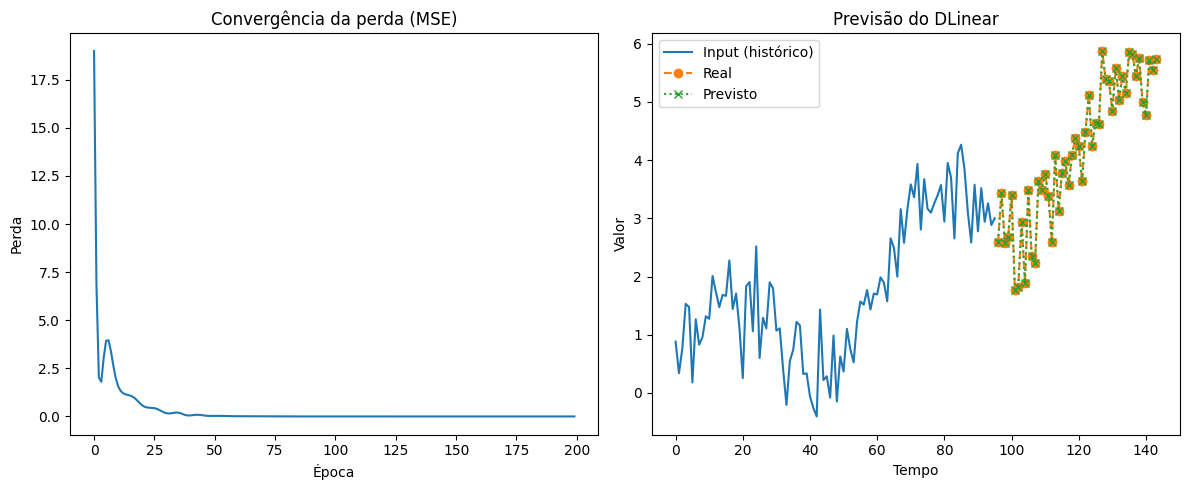

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Modelo DLinear simplificado
class DLinear(nn.Module):
    def __init__(self, input_length: int, pred_length: int, kernel_size: int = 25):
        super(DLinear, self).__init__()
        self.input_length = input_length
        self.pred_length = pred_length
        self.kernel_size = kernel_size

        self.linear_trend = nn.Linear(input_length, pred_length)
        self.linear_residual = nn.Linear(input_length, pred_length)
        self.moving_avg = torch.ones(1, 1, kernel_size) / kernel_size

    def moving_average(self, x: torch.Tensor) -> torch.Tensor:
        padding = self.kernel_size // 2
        trend = F.conv1d(x, self.moving_avg.to(x.device), padding=padding, groups=1)
        return trend

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        trend = self.moving_average(x)
        seasonal = x - trend
        out_trend = self.linear_trend(trend)
        out_seasonal = self.linear_residual(seasonal)
        return out_trend + out_seasonal

# Simular uma série temporal com tendência e ruído
np.random.seed(0)
timesteps = 300
input_len = 96
pred_len = 48

full_series = np.linspace(0, 10, timesteps) + np.sin(np.linspace(0, 10 * np.pi, timesteps)) + np.random.normal(0, 0.5, timesteps)

# Preparar dados para o modelo
x_input = torch.tensor(full_series[0:input_len], dtype=torch.float32).view(1, 1, -1)
y_true = torch.tensor(full_series[input_len:input_len+pred_len], dtype=torch.float32).view(1, 1, -1)

# Inicializar modelo e otimizador
model = DLinear(input_length=input_len, pred_length=pred_len, kernel_size=25)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Treinamento simples
losses = []
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    output = model(x_input)
    loss = loss_fn(output, y_true)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Previsão final
model.eval()
with torch.no_grad():
    y_pred = model(x_input).view(-1).numpy()

# Plotar curva de perda
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Convergência da perda (MSE)")
plt.xlabel("Época")
plt.ylabel("Perda")

# Plotar previsão vs. real
plt.subplot(1, 2, 2)
plt.plot(range(input_len), full_series[0:input_len], label="Input (histórico)")
plt.plot(range(input_len, input_len + pred_len), full_series[input_len:input_len + pred_len], label="Real", marker='o', linestyle='--')
plt.plot(range(input_len, input_len + pred_len), y_pred, label="Previsto", marker='x', linestyle=':')
plt.title("Previsão do DLinear")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()


Criando dados...
Dados de treino: 336 amostras
Dados de teste: 85 amostras

Treinando modelo...
Época 50/300, Loss: 0.2298
Época 100/300, Loss: 0.2255
Época 150/300, Loss: 0.2253
Época 200/300, Loss: 0.2252
Época 250/300, Loss: 0.2252
Época 300/300, Loss: 0.2252

Avaliando modelo...
Loss no teste: 0.4049


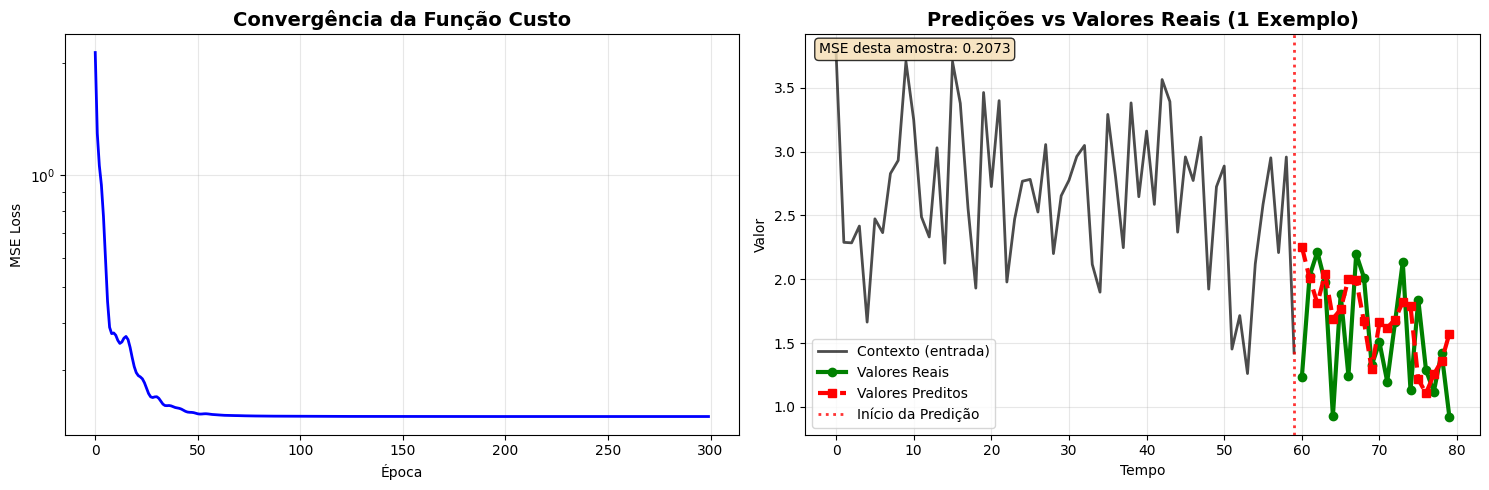


📊 Métricas Finais:
MSE: 0.4049
MAE: 0.4958
Melhoria na loss: 2.1271 → 0.2252 (89.4% redução)


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Modelo DLinear minimalista
class DLinear(nn.Module):
    def __init__(self, seq_len, pred_len):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        
        # Apenas duas camadas lineares: uma para tendência, outra para sazonal
        self.trend_proj = nn.Linear(seq_len, pred_len)
        self.seasonal_proj = nn.Linear(seq_len, pred_len)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        
        # Média móvel simples para extrair tendência (kernel fixo de tamanho 25)
        kernel_size = min(25, self.seq_len // 4)  # Ajusta automaticamente
        x_padded = F.pad(x.unsqueeze(1), (kernel_size//2, kernel_size//2), mode='replicate')
        trend = F.avg_pool1d(x_padded, kernel_size=kernel_size, stride=1).squeeze(1)
        
        # Componente sazonal = original - tendência
        seasonal = x - trend
        
        # Projetar ambos para o futuro
        trend_out = self.trend_proj(trend)
        seasonal_out = self.seasonal_proj(seasonal)
        
        return trend_out + seasonal_out

# Criar dados sintéticos simples
def create_data():
    np.random.seed(42)
    t = np.linspace(0, 10, 500)
    # Tendência + sazonalidade + ruído
    data = 0.1 * t + 2 * np.sin(t) + 0.5 * np.random.randn(500)
    return data.astype(np.float32)

# Criar janelas deslizantes
def create_windows(data, seq_len, pred_len):
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+pred_len])
    return torch.tensor(X), torch.tensor(y)

# Parâmetros
seq_len = 60  # Janela de entrada
pred_len = 20  # Janela de predição
epochs = 300
lr = 0.01

# Preparar dados
print("Criando dados...")
data = create_data()
X, y = create_windows(data, seq_len, pred_len)

# Dividir em treino e teste (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Dados de treino: {len(X_train)} amostras")
print(f"Dados de teste: {len(X_test)} amostras")

# Modelo e otimizador
model = DLinear(seq_len, pred_len)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

# Treinamento
print("\nTreinando modelo...")
train_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    pred = model(X_train)
    loss = criterion(pred, y_train)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f'Época {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# Avaliação
print("\nAvaliando modelo...")
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f'Loss no teste: {test_loss.item():.4f}')

# Plotar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Convergência da função custo
ax1.plot(train_losses, 'b-', linewidth=2)
ax1.set_title('Convergência da Função Custo', fontsize=14, fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('MSE Loss')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # Escala log para melhor visualização

# Gráfico 2: Predições vs Valores Reais (UMA AMOSTRA CLARA)
# Pegar apenas uma amostra do meio do conjunto de teste
sample_idx = len(X_test) // 2

# Entrada (contexto)
x_context = range(seq_len)
context_data = X_test[sample_idx].numpy()

# Valores reais e preditos
x_future = range(seq_len, seq_len + pred_len)
real_data = y_test[sample_idx].numpy()
pred_data = test_pred[sample_idx].numpy()

ax2.set_title('Predições vs Valores Reais (1 Exemplo)', fontsize=14, fontweight='bold')

# Plotar contexto (entrada do modelo)
ax2.plot(x_context, context_data, 'k-', linewidth=2, label='Contexto (entrada)', alpha=0.7)

# Plotar valores reais vs preditos
ax2.plot(x_future, real_data, 'go-', linewidth=3, markersize=6, label='Valores Reais')
ax2.plot(x_future, pred_data, 'rs--', linewidth=3, markersize=6, label='Valores Preditos')

# Linha vertical separando contexto de predição
ax2.axvline(x=seq_len-1, color='red', linestyle=':', linewidth=2, alpha=0.8, label='Início da Predição')

ax2.set_xlabel('Tempo')
ax2.set_ylabel('Valor')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Calcular erro para esta amostra específica
sample_mse = torch.mean((test_pred[sample_idx] - y_test[sample_idx])**2).item()
ax2.text(0.02, 0.98, f'MSE desta amostra: {sample_mse:.4f}', 
         transform=ax2.transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# Estatísticas finais
mae = torch.mean(torch.abs(test_pred - y_test)).item()
print(f"\n📊 Métricas Finais:")
print(f"MSE: {test_loss.item():.4f}")
print(f"MAE: {mae:.4f}")
print(f"Melhoria na loss: {train_losses[0]:.4f} → {train_losses[-1]:.4f} ({((train_losses[0]-train_losses[-1])/train_losses[0]*100):.1f}% redução)")